{'topic': '猫', 'joke': '好的，这是一个关于猫的简短笑话：\n\n**问：** 为什么猫咪总是对昂贵的猫窝不屑一顾，却对一个普通的纸箱情有独钟？\n\n**答：** 因为它们深知，真正的乐趣，往往在“包装”里！', 'improved_joke': '好的，让我们在原有的基础上，添加更多双关语，让它更“喵”趣横生！\n\n**问：** 为什么猫咪总是对昂贵的猫窝不屑一顾，却对一个普通的纸箱情有独钟？\n\n**答：** 哈哈，这其中自有它们的“**猫腻**”！猫咪们深知，那些昂贵的猫窝，不过是“虚有其表”，真正的乐趣和舒适，往往藏在最“朴实无华”的“**包装**”里！它们可不会被“表面功夫”所迷惑，而是懂得“**箱**”当有意思的生活哲学！\n\n---\n\n**解释新增的双关语：**\n\n1.  **猫腻 (māonì):** 原意是“暗中的花招、不为人知的秘密或不正当的勾当”。在这里，它巧妙地结合了“猫”这个字，暗示了猫咪们独特的、只有它们自己才懂的“小秘密”或“小聪明”。\n2.  **箱 (xiāng) 当 (dāng):** “箱”是纸箱的“箱”，与“相当”的“相”谐音。所以“箱当有意思”听起来就像“相当有意思”，强调了纸箱带来的乐趣是“非常”有意思的。\n\n这样一来，笑话不仅保留了原有的“包装”梗，还增加了“猫腻”和“箱当”两个新的双关语，让整个回答充满了猫咪特有的狡黠和幽默感！', 'final_joke': '好的，这个笑话已经很棒了，双关语用得巧，猫咪的“哲学”也很有趣。现在，让我们来给它一个出人意料的反转，揭示猫咪们更“深藏不露”的“猫腻”！\n\n---\n\n**问：** 为什么猫咪总是对昂贵的猫窝不屑一顾，却对一个普通的纸箱情有独钟？\n\n**答：** 哈哈，这其中自有它们的“**猫腻**”！猫咪们深知，那些昂贵的猫窝，不过是“虚有其表”，真正的乐趣和舒适，往往藏在最“朴实无华”的“**包装**”里！它们可不会被“表面功夫”所迷惑，而是懂得“**箱**”当有意思的生活哲学！\n\n---\n\n**出人意料的反转：**\n\n然而，这仅仅是它们迷惑两脚兽的“**障眼法**”！它们对纸箱的真正情有独钟，并非仅仅为了舒适或哲学，而是看中了纸箱的“**多功能性**”和“**可塑性**”！\n\n其实，猫咪们把纸箱当作

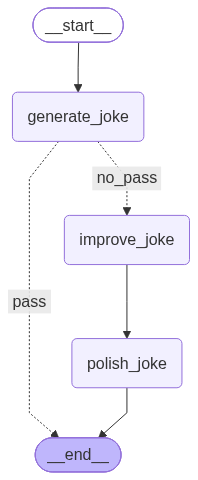

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	generate_joke(generate_joke)
	improve_joke(improve_joke)
	polish_joke(polish_joke)
	__end__([<p>__end__</p>]):::last
	__start__ --> generate_joke;
	generate_joke -. &nbsp;pass&nbsp; .-> __end__;
	generate_joke -. &nbsp;no_pass&nbsp; .-> improve_joke;
	improve_joke --> polish_joke;
	polish_joke --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [1]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv(override=True)
from rich import print as rprint

GEMINI_API_KEY=os.getenv("GEMINI_API_KEY")
GEMINI_BASE_URL=os.getenv("GEMINI_BASE_URL")

model = init_chat_model(
  model="gemini-2.5-flash",
  model_provider="google_genai",
  api_key=GEMINI_API_KEY,
  transport="rest"  # 强制使用 REST 协议
)

# 图状态
class OverAllState(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str

# 节点
def generate_joke(state: OverAllState) -> OverAllState:
    """第一次调用大模型，生成初始笑话"""

    msg = model.invoke(
        [HumanMessage(content=f"写一个关于“{state['topic']}”的简短笑话")]
    )
    return {"joke": msg.content}

def check_punchline(state: OverAllState) -> Literal["pass", "no_pass"]:
    """判断笑话中是否包含包袱"""

    # 简单判断：笑话中是否包含问号或感叹号
    if "?" in state["joke"] or "!" in state["joke"]:
        return "pass"
    return "no_pass"

def improve_joke(state: OverAllState) -> OverAllState:
    """第二次调用大模型，通过添加双关语改进笑话"""

    msg = model.invoke(
        [HumanMessage(content=f"通过添加双关语，让下面这个笑话变得更有趣：\n{state['joke']}")]
    )
    return {"improved_joke": msg.content}

def polish_joke(state: OverAllState) -> OverAllState:
    """第三次调用大模型，对笑话进行最终润色"""

    msg = model.invoke(
        [HumanMessage(content=f"为下面这个笑话添加一个出人意料的反转：\n{state['improved_joke']}")]
    )
    return {"final_joke": msg.content}

# 构建工作流
builder = StateGraph(state_schema=OverAllState)

# 添加节点
builder.add_node("generate_joke", generate_joke)
builder.add_node("improve_joke", improve_joke)
builder.add_node("polish_joke", polish_joke)

# 添加边，连接各个节点
builder.add_edge(START, "generate_joke")
builder.add_conditional_edges(
    "generate_joke",
    check_punchline,
    {
        "no_pass": "improve_joke",
        "pass": END,
    },
)
builder.add_edge("improve_joke", "polish_joke")
builder.add_edge("polish_joke", END)

# 编译工作流
graph = builder.compile()

# 调用工作流
response = graph.invoke({"topic": "猫"})
print(response)

# 绘制拓扑结构
from IPython.display import display
display(graph)

raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)